## INTRO TO MACHINE LEARNING

The purpose of this project is to take Moringa students and any other person interested through the machine learning process

I will create a scenario where we have a business question, a business objective and what the expected outcome is

## Business Question
IncomeProt LTD is looking to determine who is most likely to earn more than 50k usd to offer them their premium services earlier in their customer journey and also looking to help those under 50k usd to grow their income and savings account. They have provided a dataset containing the first few users whose income has been verified and want a prediction model that they can embed in their customer process to group users.

## Business Objective
* Give an analysis of the current dataset and what it entails
* Build a machine learning model that IncomeProt can use to group their users 
* Develop a recommendation based on the data of what each user is able to afford

## Expected Outcome
- Machine Learning Model
- Informed Decision

## Data Info

The data is from UCI datasets, called Adult, it is a very old dataset from a Census done in 1994, it contains training dataset and a validation dataset, a total of 48842 rows and 14 columns.

The target variable is income which is a binary variable >50k, <=50k.

The other columns are:
- **age** - Age of user
- **workclass** - Whether a user is self employed, employed etc
- **fnlwgt** - final weight t is an estimate by the U.S. Census Bureau of how many people in the real-world population share the exact same demographic profile as that specific survey row
- **education** - Users education level
- **education-num** - Users education level in numerical format
- **marital-status** - Users marital status eg Divorced, Never married
- **occupation** - Users profession
- **relationship** - Users relation to anyone else
- **race** - Users race
- **sex** - Users gender
- **capital-gain** - a continuous numerical feature that measures an individual's recorded income from investment sources, such as profits from selling stocks or real estate, distinct from regular wages or salary
- **capital-loss** - a continuous numerical feature representing an individual's recorded capital losses (such as from the sale of stocks or real estate) over the previous year
- **hours-per-week** - How many hours users work per week
- **native-country** - Where user is originally from

In [1]:
#Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import xgboost as xgb


columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
df = pd.read_csv("adult/adult.data",header=None, names=columns, skipinitialspace=True)
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
#Why use the skipinitialspace

# has_leading_space = df[df['workclass'].str.startswith(' ')]
# print(has_leading_space['workclass'].head())

## Data Info

In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
categorical_columns = ["workclass", "education", "marital-status", "occupation", "relationship",
"race", "sex", "native-country"]

for col in categorical_columns:
    col_value_count = df[col].value_counts()
    print(f"\n {col} \n Value Counts:\n {col_value_count}")


 workclass 
 Value Counts:
 workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

 education 
 Value Counts:
 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

 marital-status 
 Value Counts:
 marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype

## Data Cleaning

In [7]:
for cat in categorical_columns:
    df[cat] = df[cat].replace({'?':'Unknown'})

In [8]:
for col in categorical_columns:
    col_value_count = df[col].value_counts()
    print(f"\n {col} \n Value Counts:\n {col_value_count}")


 workclass 
 Value Counts:
 workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

 education 
 Value Counts:
 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

 marital-status 
 Value Counts:
 marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype

In [9]:
def Statistics(df,col):
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    min = df[col].min()
    max = df[col].max()

    print(f"\n Statistics \n Mean of {col}: {mean} \n Median of {col}: {median} \n Standard Deviation of {col}: {std} \n Minimum of {col}: {min} \n Maximum of {col}: {max}")

In [10]:
for col in df.select_dtypes(include='number'):
    print(col)

age
fnlwgt
education-num
capital-gain
capital-loss
hours-per-week


In [11]:
for col in df.select_dtypes(include='number'):
    Statistics(df, col)


 Statistics 
 Mean of age: 38.58164675532078 
 Median of age: 37.0 
 Standard Deviation of age: 13.640432553581341 
 Minimum of age: 17 
 Maximum of age: 90

 Statistics 
 Mean of fnlwgt: 189778.36651208502 
 Median of fnlwgt: 178356.0 
 Standard Deviation of fnlwgt: 105549.97769702224 
 Minimum of fnlwgt: 12285 
 Maximum of fnlwgt: 1484705

 Statistics 
 Mean of education-num: 10.0806793403151 
 Median of education-num: 10.0 
 Standard Deviation of education-num: 2.5727203320673877 
 Minimum of education-num: 1 
 Maximum of education-num: 16

 Statistics 
 Mean of capital-gain: 1077.6488437087312 
 Median of capital-gain: 0.0 
 Standard Deviation of capital-gain: 7385.292084840338 
 Minimum of capital-gain: 0 
 Maximum of capital-gain: 99999

 Statistics 
 Mean of capital-loss: 87.303829734959 
 Median of capital-loss: 0.0 
 Standard Deviation of capital-loss: 402.9602186489997 
 Minimum of capital-loss: 0 
 Maximum of capital-loss: 4356

 Statistics 
 Mean of hours-per-week: 40.4374

Capital gain and capital loss are kinda skewed looking at the statistics

## Exploratory Data Analysis

### Univariate Data Analusis

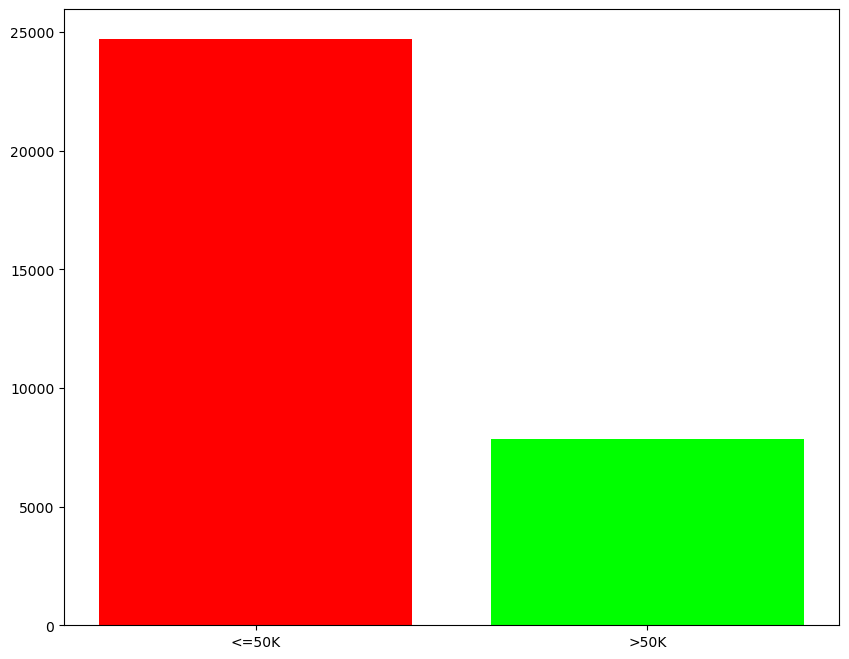

In [12]:
# Target Column
target_value_counts = df['income'].value_counts()
color = ['red', 'lime']
plt.figure(figsize=(10,8))
plt.bar(x=target_value_counts.index, height=target_value_counts.values, color=color)
plt.show()

## Histogram

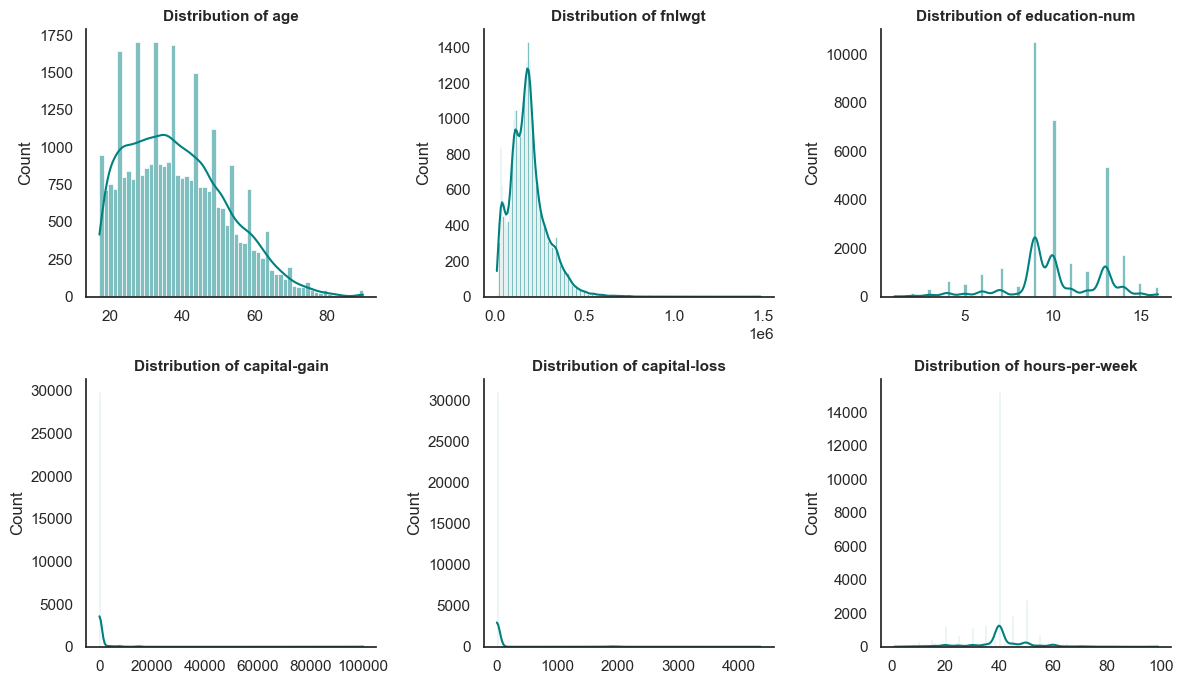

In [13]:
import math 
num_cols = df.select_dtypes(include="number").columns
n_cols = len(num_cols)

# 2. Set grid dimensions (3 columns per row)
grid_cols = 3
grid_rows = math.ceil(n_cols / grid_cols)

# 3. Create the grid figure
sns.set_theme(style="white")
fig, axes = plt.subplots(
    nrows=grid_rows, ncols=grid_cols, figsize=(grid_cols * 4, grid_rows * 3.5)
)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="teal",
        ax=axes[i],
        edgecolor="w",
        linewidth=0.5,
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, weight="bold")
    axes[i].set_xlabel("")  # Clean up X axis label since title has the name
    sns.despine(ax=axes[i])  # Remove top and right borders

# 5. Hide empty subplot frames
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/var/folders/8q/96m6p9f10bz_c_ph7l1cwdqw0000gn/T/ipykernel_1047/2712216723.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


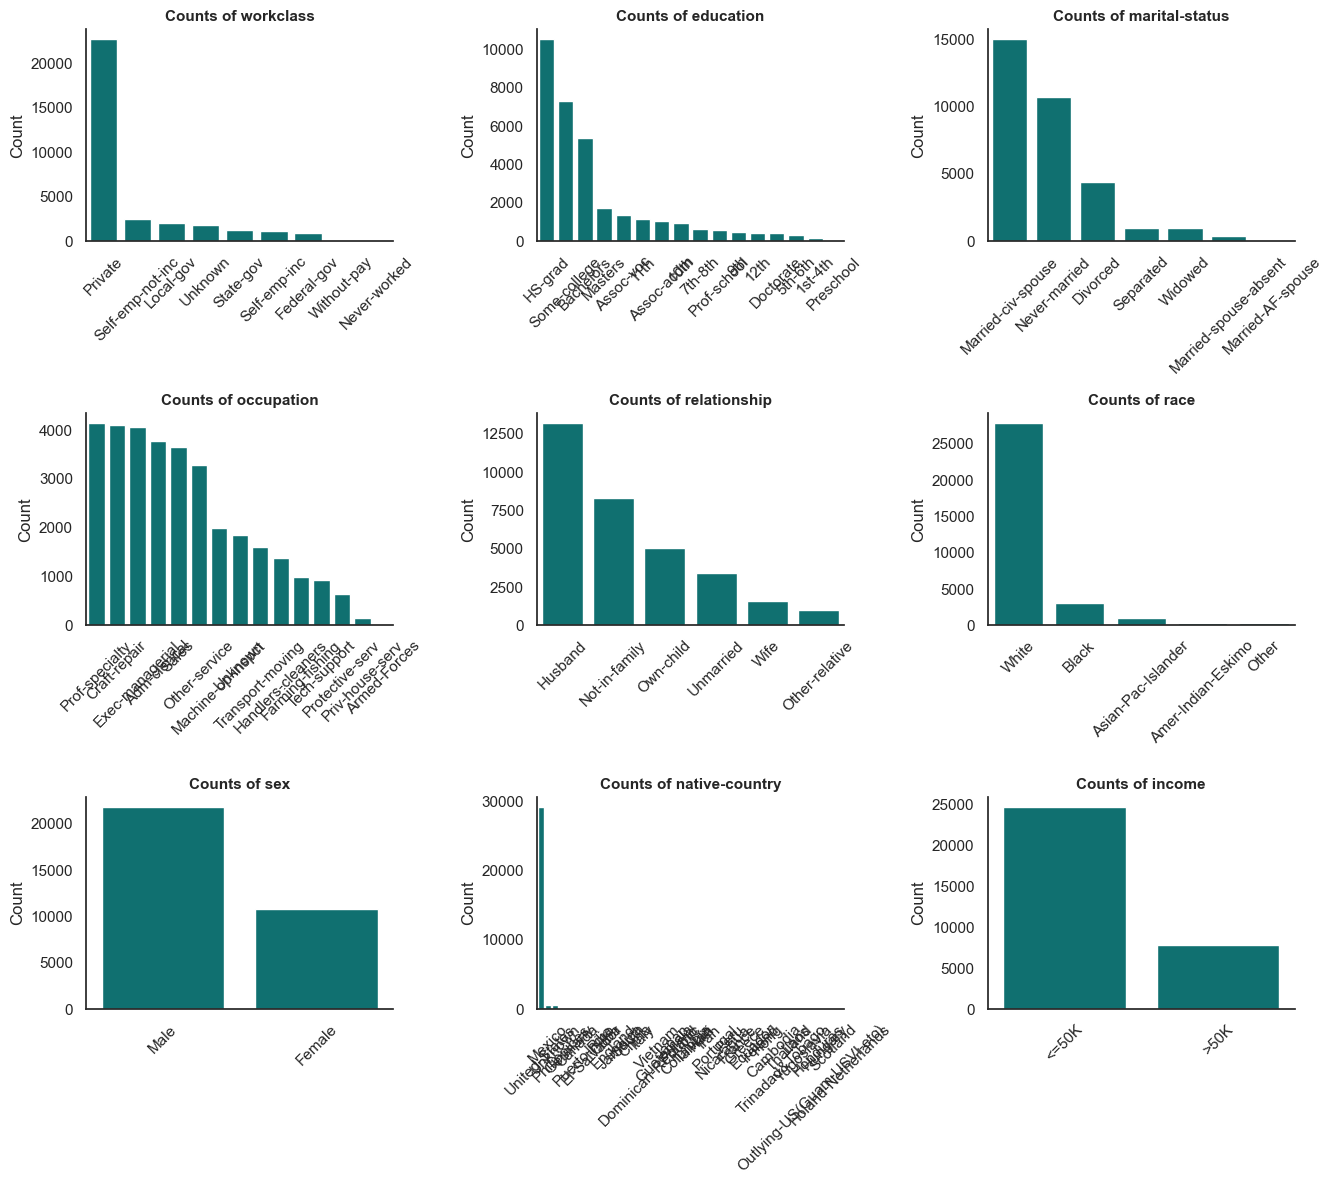

In [14]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
n_cols = len(cat_cols)

# 2. Set grid dimensions (3 columns per row)
grid_cols = 3
grid_rows = math.ceil(n_cols / grid_cols)

# 3. Create the grid figure
sns.set_theme(style="white")
fig, axes = plt.subplots(
    nrows=grid_rows, ncols=grid_cols, figsize=(grid_cols * 4.5, grid_rows * 4)
)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Sort categories by frequency so the largest bars are on the left
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        color="teal",  # Keeps the same teal theme
        ax=axes[i],
    )

    # Styling adjustments
    axes[i].set_title(f"Counts of {col}", fontsize=11, weight="bold")
    axes[i].set_xlabel("")  # Hide X axis label to reduce clutter
    axes[i].set_ylabel("Count")

    # Rotate X-axis labels if category names are long
    axes[i].tick_params(axis="x", rotation=45)

    sns.despine(ax=axes[i])  # Remove top and right borders

# 5. Hide empty subplot frames
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate Analysis

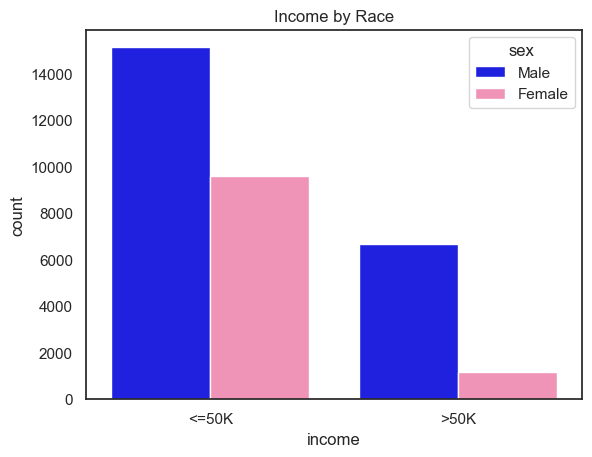

In [15]:
sns.countplot(data=df, x='income', hue='sex',palette=['#0000FF',"#FF85B3"],)

# Display the plot
plt.title('Income by Race')
plt.show()

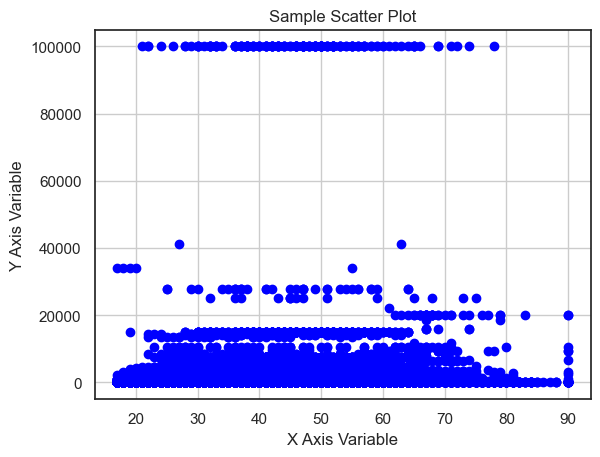

In [16]:
plt.scatter(df["age"], df["capital-gain"], color="blue", marker="o")

# 3. Add labels and display
plt.title("Sample Scatter Plot")
plt.xlabel("X Axis Variable")
plt.ylabel("Y Axis Variable")
plt.grid(True)
plt.show()

In [17]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


/var/folders/8q/96m6p9f10bz_c_ph7l1cwdqw0000gn/T/ipykernel_1047/3970156396.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [18]:
categorical_features = [
    col for col in categorical_cols
    if col != "income"
]

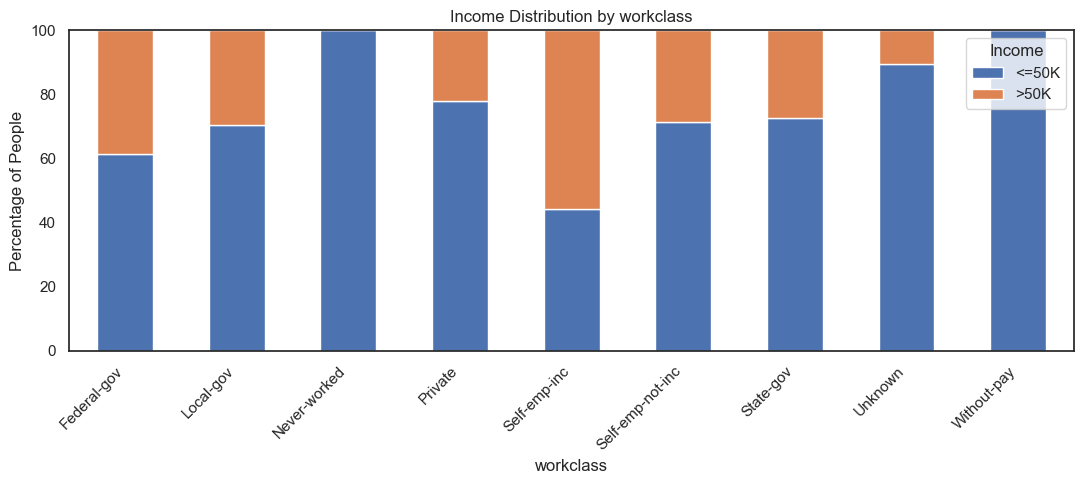

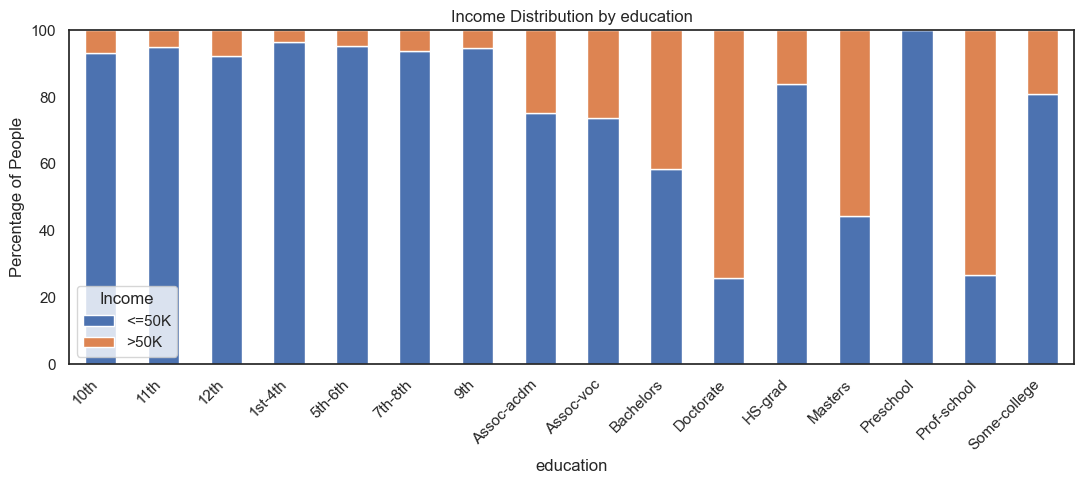

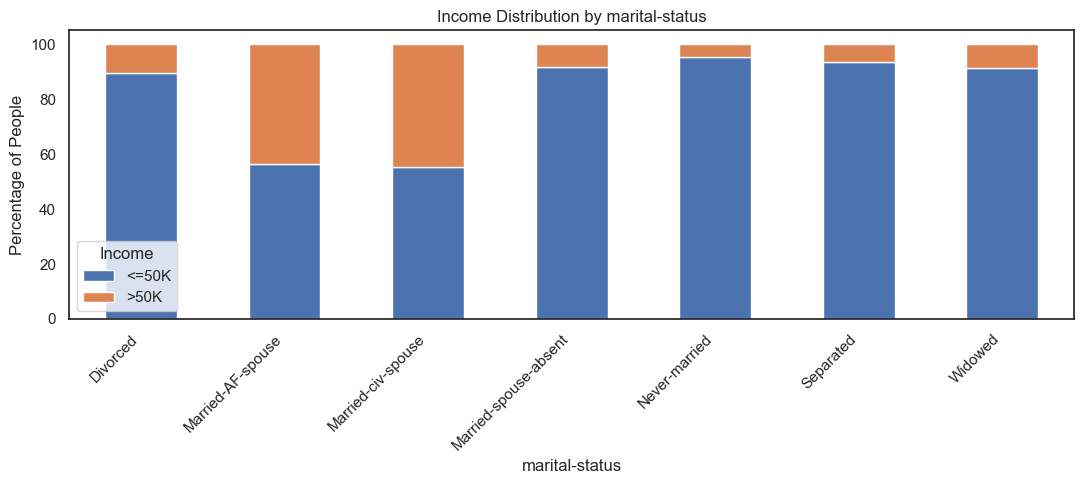

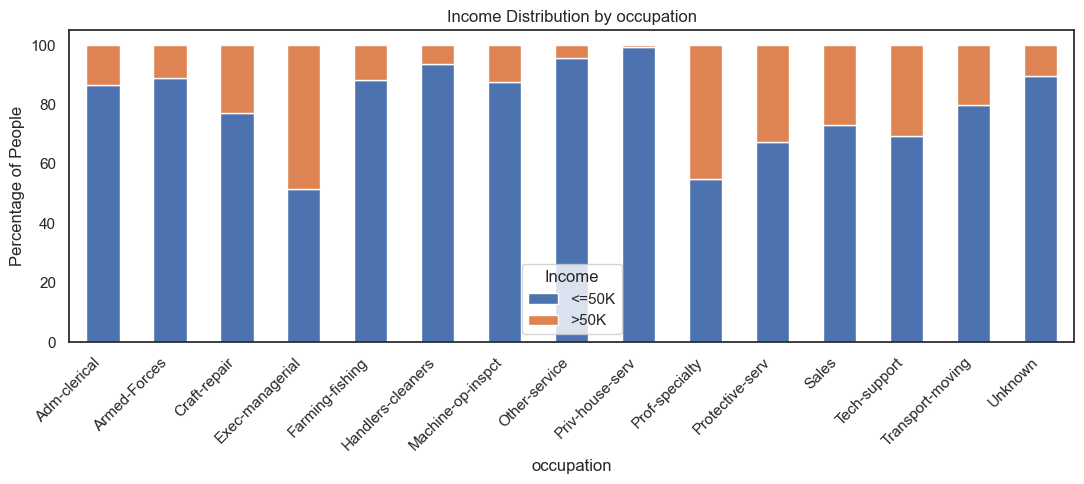

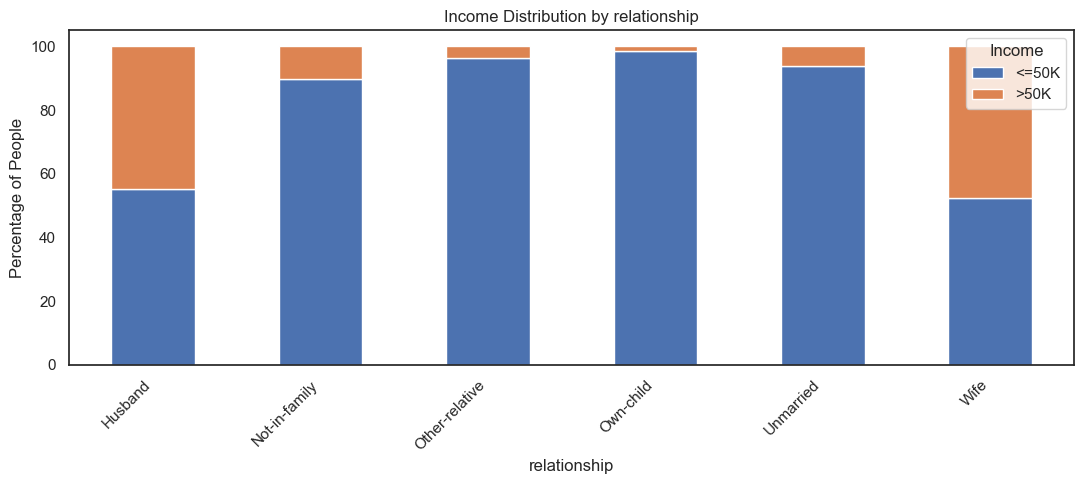

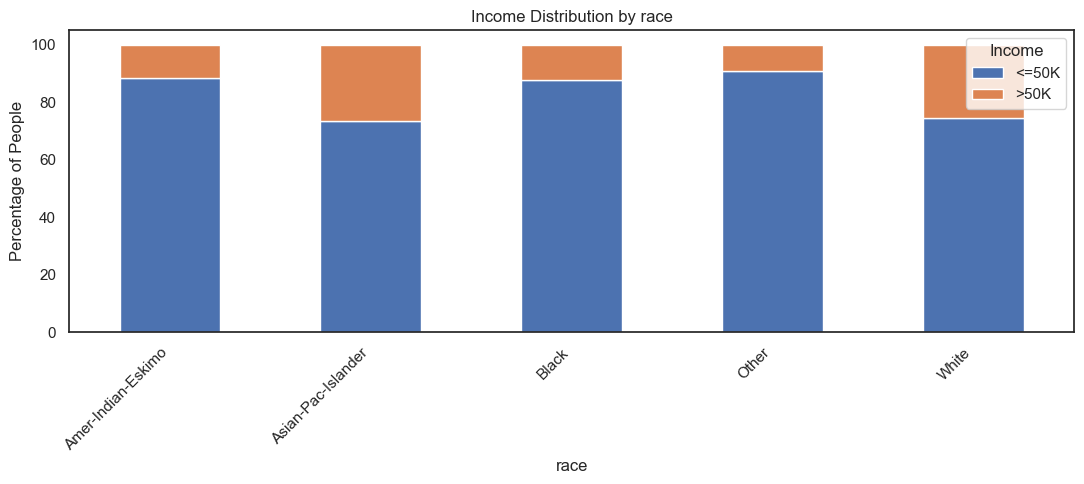

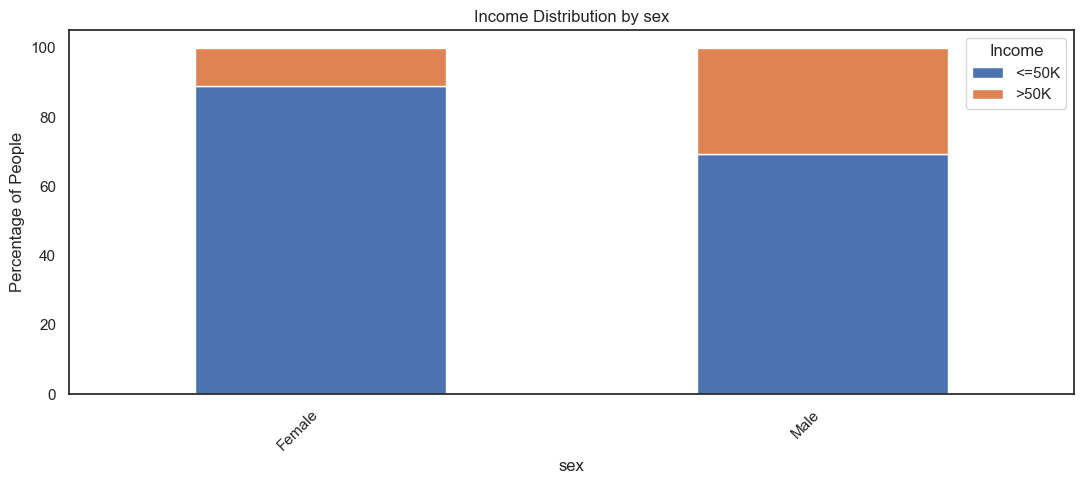

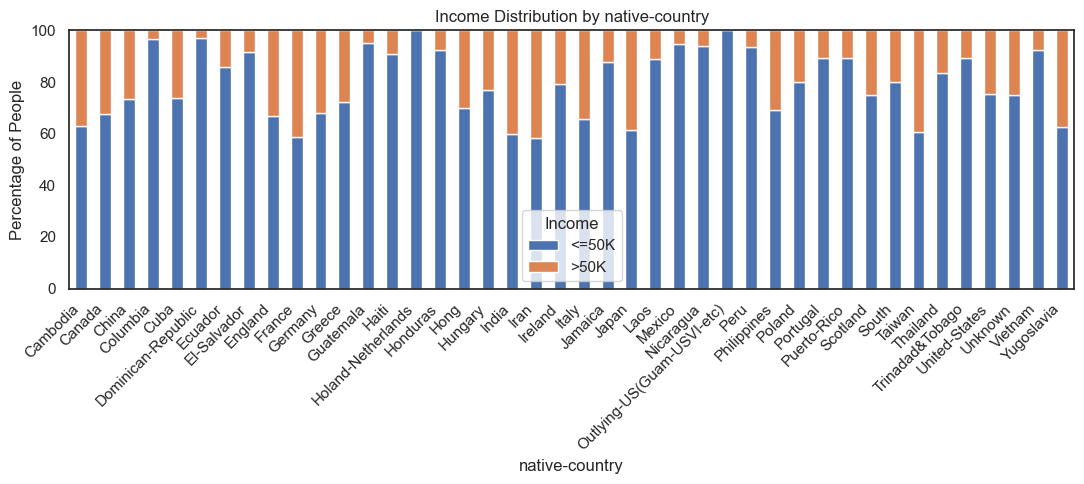

In [19]:
for col in categorical_features:
    table = pd.crosstab(
        df[col],
        df["income"],
        normalize="index"
    ) * 100

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 5)
    )

    plt.title(f"Income Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage of People")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Income")
    plt.tight_layout()
    plt.show()

#### High Income Rate by category

In [20]:
df["income_clean"] = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

df["high_income"] = df["income_clean"].eq(">50K").astype(int)

In [21]:
education_high_income = (
    df.groupby("education", observed=True)["high_income"]
      .agg(
          people="size",
          high_income_rate="mean"
      )
      .assign(
          high_income_rate=lambda x: x["high_income_rate"] * 100
      )
      .sort_values("high_income_rate", ascending=False)
)

education_high_income.round(1)

,people,high_income_rate
education,,
Doctorate,413,74.1
Prof-school,576,73.4
Masters,1723,55.7
Bachelors,5355,41.5
Assoc-voc,1382,26.1
Assoc-acdm,1067,24.8
Some-college,7291,19.0
HS-grad,10501,16.0
12th,433,7.6


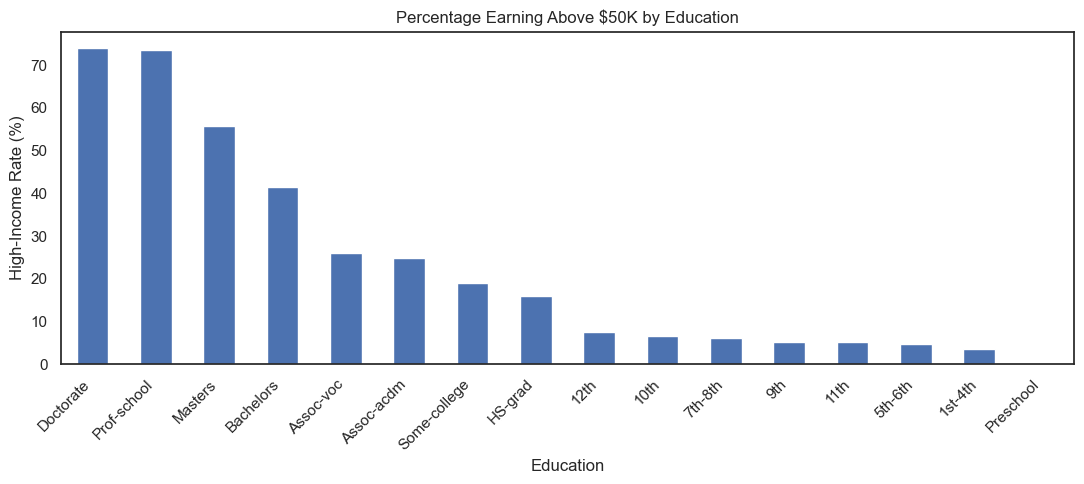

In [22]:
education_high_income["high_income_rate"].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Percentage Earning Above $50K by Education")
plt.xlabel("Education")
plt.ylabel("High-Income Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Multivariate Analysis

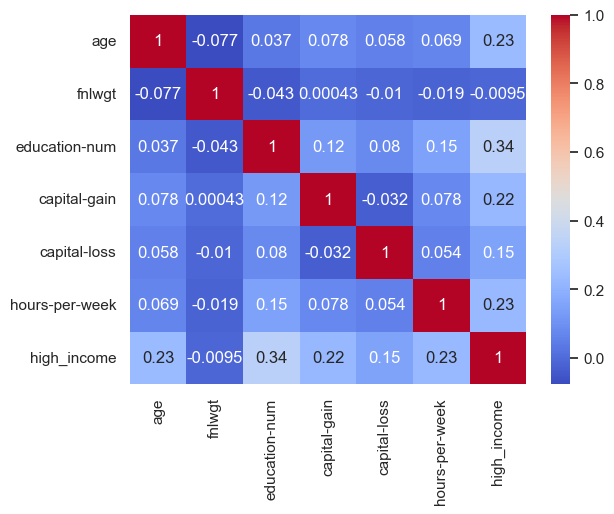

In [23]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap="coolwarm")
plt.show()

In [24]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate bias-corrected Cramér's V between two categorical variables.
    """
    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.empty:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()

    if n <= 1:
        return np.nan

    phi2 = chi2 / n
    rows, cols = confusion_matrix.shape

    phi2_corrected = max(
        0,
        phi2 - ((cols - 1) * (rows - 1)) / (n - 1)
    )

    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    cols_corrected = cols - ((cols - 1) ** 2) / (n - 1)

    denominator = min(cols_corrected - 1, rows_corrected - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2_corrected / denominator)

In [25]:
categorical_for_matrix = df.select_dtypes(
    include=["object", "category"]
).columns

cramers_matrix = pd.DataFrame(
    index=categorical_for_matrix,
    columns=categorical_for_matrix,
    dtype=float
)

for col1 in categorical_for_matrix:
    for col2 in categorical_for_matrix:
        cramers_matrix.loc[col1, col2] = cramers_v(
            df[col1],
            df[col2]
        )

cramers_matrix.round(2)

/var/folders/8q/96m6p9f10bz_c_ph7l1cwdqw0000gn/T/ipykernel_1047/3834299763.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_for_matrix = df.select_dtypes(


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income,income_clean
workclass,1.00,0.10,0.08,0.40,0.10,0.05,0.15,0.03,0.18,0.18
education,0.10,1.00,0.09,0.19,0.12,0.07,0.09,0.13,0.37,0.37
marital-status,0.08,0.09,1.00,0.13,0.49,0.08,0.46,0.06,0.45,0.45
occupation,0.40,0.19,0.13,1.00,0.18,0.08,0.42,0.06,0.35,0.35
relationship,0.10,0.12,0.49,0.18,1.00,0.10,0.65,0.08,0.45,0.45
race,0.05,0.07,0.08,0.08,0.10,1.00,0.12,0.41,0.10,0.10
sex,0.15,0.09,0.46,0.42,0.65,0.12,1.00,0.06,0.22,0.22
native-country,0.03,0.13,0.06,0.06,0.08,0.41,0.06,1.00,0.09,0.09
income,0.18,0.37,0.45,0.35,0.45,0.10,0.22,0.09,1.00,1.00
income_clean,0.18,0.37,0.45,0.35,0.45,0.10,0.22,0.09,1.00,1.00


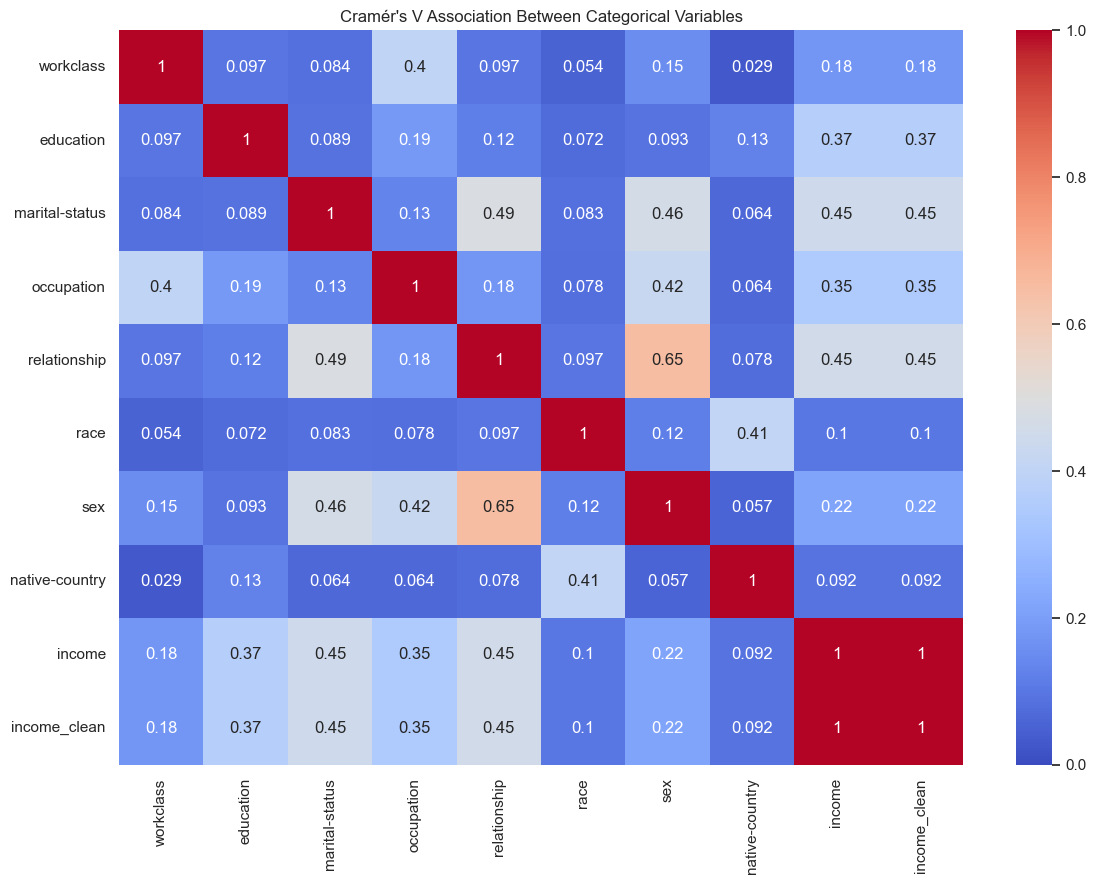

In [26]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Cramér's V Association Between Categorical Variables")
plt.tight_layout()
plt.show()

In [27]:
categorical_income_association = pd.Series({
    col: cramers_v(df[col], df["income_clean"])
    for col in categorical_features
}).sort_values(ascending=False)

categorical_income_association

relationship      0.453423
marital-status    0.447205
education         0.368219
occupation        0.351286
sex               0.215836
workclass         0.178524
race              0.100203
native-country    0.092107
dtype: float64

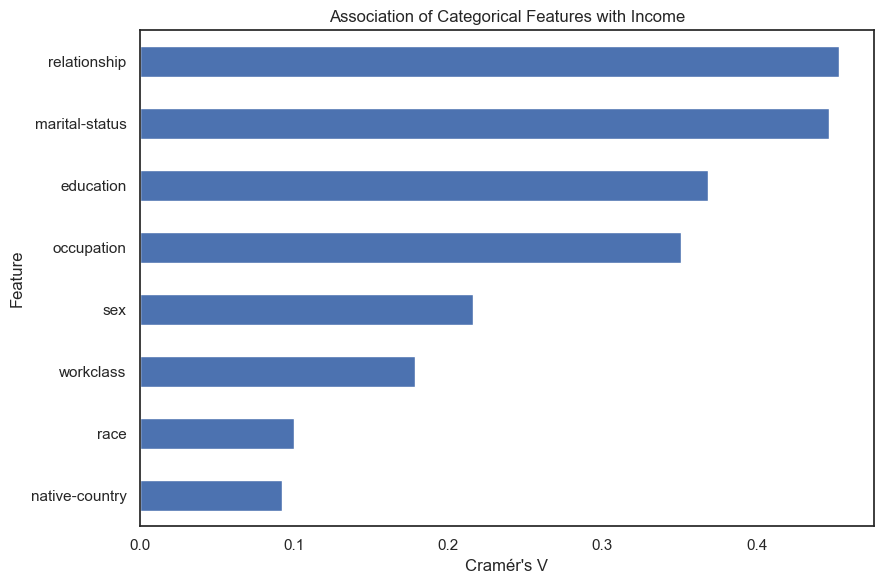

In [28]:
categorical_income_association.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Association of Categorical Features with Income")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Cramér’s V tells us whether two variables are associated, but it does not tell us that one causes the other.

In [29]:
education_sex_income = (
    df.groupby(
        ["education", "sex"],
        observed=True
    )["high_income"]
    .agg(
        people="size",
        high_income_rate="mean"
    )
    .reset_index()
)

education_sex_income["high_income_rate"] *= 100

education_sex_income.head()

,education,sex,people,high_income_rate
0,10th,Female,295,1.016949
1,10th,Male,638,9.247649
2,11th,Female,432,1.851852
3,11th,Male,743,6.998654
4,12th,Female,144,2.777778


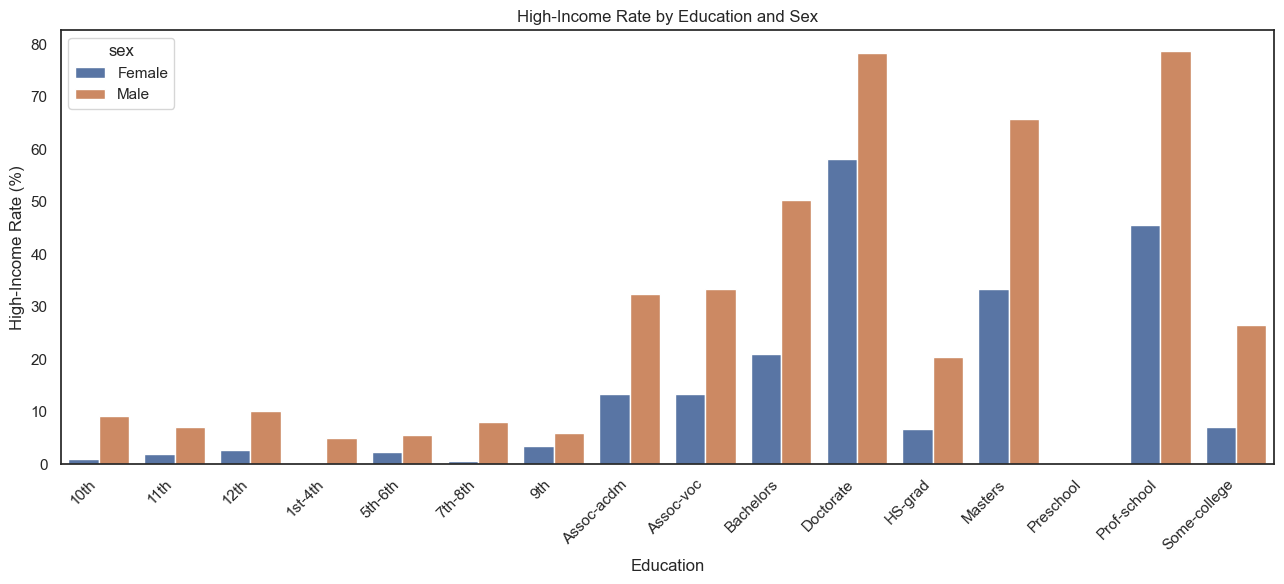

In [30]:
plt.figure(figsize=(13, 6))

sns.barplot(
    data=education_sex_income,
    x="education",
    y="high_income_rate",
    hue="sex"
)

plt.title("High-Income Rate by Education and Sex")
plt.xlabel("Education")
plt.ylabel("High-Income Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

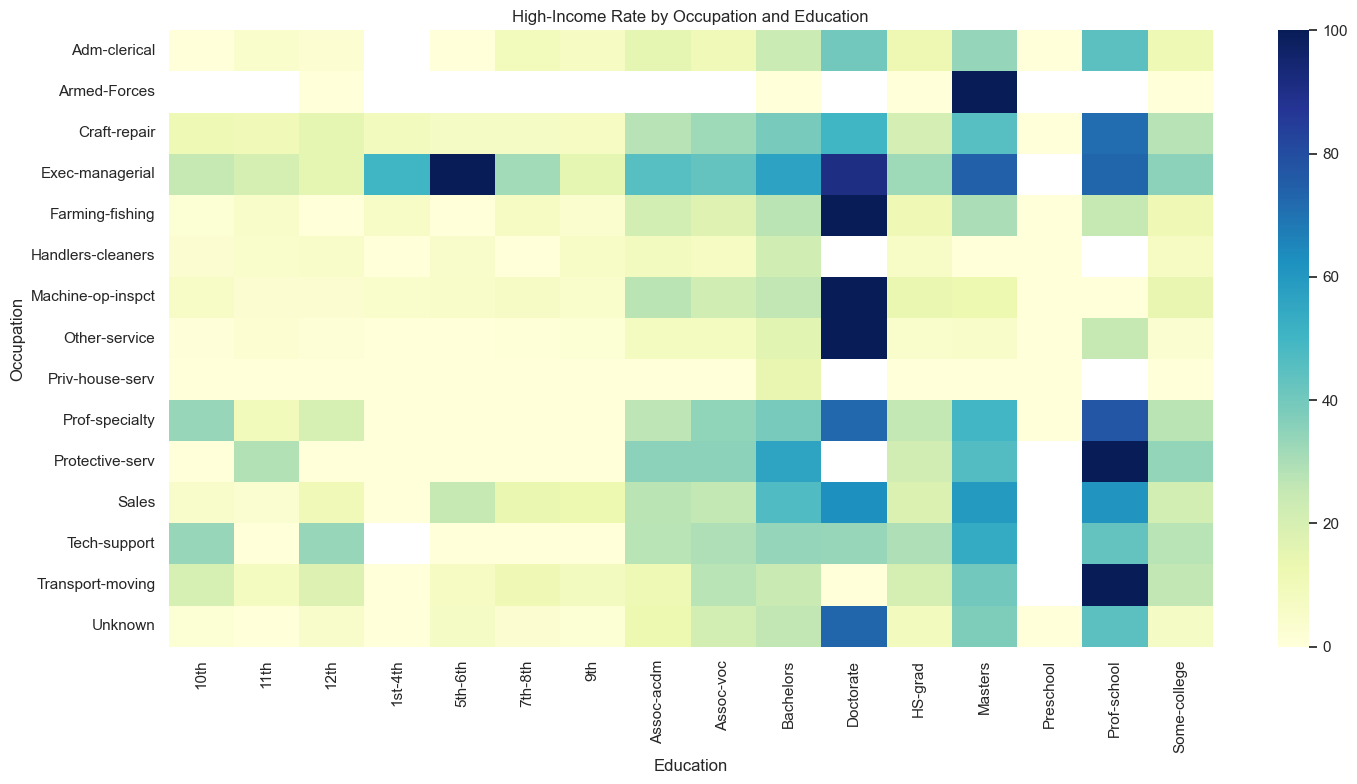

In [31]:
occupation_education_income = pd.pivot_table(
    df,
    index="occupation",
    columns="education",
    values="high_income",
    aggfunc="mean"
) * 100

plt.figure(figsize=(15, 8))

sns.heatmap(
    occupation_education_income,
    annot=False,
    cmap="YlGnBu"
)

plt.title("High-Income Rate by Occupation and Education")
plt.xlabel("Education")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

## Modeling

### Baseline Model

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, accuracy_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImPipeline

In [33]:
df.shape

(32561, 17)

In [34]:
df["income_binary"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [35]:
df.columns.to_list()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income',
 'income_clean',
 'high_income',
 'income_binary']

In [36]:
X = df.drop(columns=['income', 'income_clean', 'high_income', 'income_binary','education'])
y = df['income_binary']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [38]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

/var/folders/8q/96m6p9f10bz_c_ph7l1cwdqw0000gn/T/ipykernel_1047/3330270739.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [39]:
categorical_cols

['workclass',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [40]:
numerical_columns = X.select_dtypes(include="number").columns.to_list()
numerical_columns

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [41]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore',drop='first')
preprocessor = ColumnTransformer(
                transformers = [(
                'num', numeric_transformer,numerical_columns),
                ('cat', categorical_transformer,categorical_cols)
                ])

In [42]:
#Now to create a pipeline that scales and fits a model
from sklearn.metrics import make_scorer


pipeline = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
recall_scorer = make_scorer(recall_score)

cv_recall_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring=recall_scorer)
cv_accuracy_scores = cross_val_score(pipeline, X_train,y_train,cv=5,scoring='accuracy')
cv_log_loss_scores = cross_val_score(pipeline, X_train,y_train,cv=5,scoring='neg_log_loss')
cv_precision_scores = cross_val_score(pipeline, X_train, y_train, cv= 5, scoring ='precision')
cv_f1_scores = cross_val_score(pipeline, X_train, y_train, cv =5, scoring = 'f1')

accuracy = np.mean(cv_accuracy_scores)
precision = np.mean(cv_precision_scores)
recall = np.mean(cv_recall_scores)
f1 = np.mean(cv_f1_scores)
log_loss = -np.mean(cv_log_loss_scores)

print("The accuracy score is:" ,accuracy)
print("The precision score is:", precision)
print("The recall score is", recall)
print("The F1 score is:", f1)
print("The log loss is:", log_loss)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

The accuracy score is: 0.811015561015561
The precision score is: 0.5750131953876559
The recall score is 0.844774462814291
The F1 score is: 0.6841647116251454
The log loss is: 0.38999145939258184


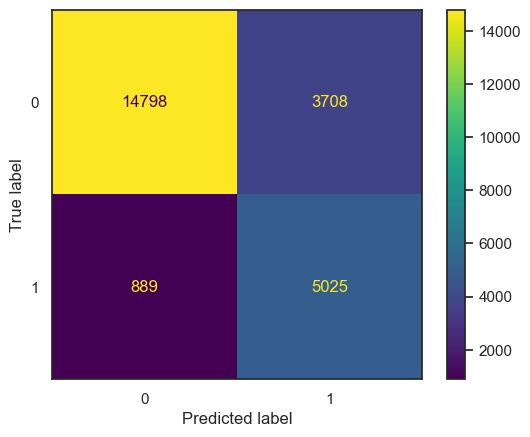

In [43]:
pipeline.fit(X_train,y_train)
ConfusionMatrixDisplay.from_estimator(estimator=pipeline, X=X_train,y=y_train)
plt.grid(False);

## Decision Tree Classifier

In [44]:
from sklearn.tree import DecisionTreeClassifier

dt = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(criterion= 'entropy',random_state=42))
])
cv_recall_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring=recall_scorer)
cv_accuracy_scores = cross_val_score(dt, X_train,y_train,cv=5,scoring='accuracy')
cv_log_loss_scores = cross_val_score(dt, X_train,y_train,cv=5,scoring='neg_log_loss')
cv_precision_scores = cross_val_score(dt, X_train, y_train, cv= 5, scoring ='precision')
cv_f1_scores = cross_val_score(dt, X_train, y_train, cv =5, scoring = 'f1')

recall2 = np.mean(cv_recall_scores)
accuracy2 = np.mean(cv_accuracy_scores)
precision2 = np.mean(cv_precision_scores)
f12 = np.mean(cv_f1_scores)
log_loss2 = -np.mean(cv_log_loss_scores)

print("The accuracy score is:" ,accuracy2)
print("The precision score is:", precision2)
print("The recall score is:", recall2)
print("The F1 score is:", f12)
print("The log loss is:", log_loss2)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

The accuracy score is: 0.8081900081900082
The precision score is: 0.5954756793630447
The recall score is: 0.6493076622713483
The F1 score is: 0.6211664607797482
The log loss is: 6.913532861368745


## KNN

In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier())
])

cv_recall_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring=recall_scorer)
cv_accuracy_scores = cross_val_score(knn, X_train,y_train,cv=5,scoring='accuracy')
cv_log_loss_scores = cross_val_score(knn, X_train,y_train,cv=5,scoring='neg_log_loss')
cv_precision_scores = cross_val_score(knn, X_train, y_train, cv= 5, scoring ='precision')
cv_f1_scores = cross_val_score(knn, X_train, y_train, cv =5, scoring = 'f1')

accuracy3 = np.mean(cv_accuracy_scores)
precision3 = np.mean(cv_precision_scores)
recall3 = np.mean(cv_recall_scores)
f13 = np.mean(cv_f1_scores)
log_loss3 = -np.mean(cv_log_loss_scores)

print("The accuracy score is:" ,accuracy3)
print("The precision score is:", precision3)
print("The recall score is:", recall3)
print("The F1 score is:", f13)
print("The log loss is:", log_loss3)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

The accuracy score is: 0.785995085995086
The precision score is: 0.5393908741484512
The recall score is: 0.7979357880177872
The F1 score is: 0.6436177110064347
The log loss is: 2.4693776206920397


In [46]:
from sklearn.ensemble import RandomForestClassifier
rfc = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

cv_recall_scores = cross_val_score(rfc, X_train, y_train, cv=5, scoring=recall_scorer)
cv_accuracy_scores = cross_val_score(rfc, X_train,y_train,cv=5,scoring='accuracy')
cv_log_loss_scores = cross_val_score(rfc, X_train,y_train,cv=5,scoring='neg_log_loss')
cv_precision_scores = cross_val_score(rfc, X_train, y_train, cv= 5, scoring ='precision')
cv_f1_scores = cross_val_score(rfc, X_train, y_train, cv =5, scoring = 'f1')

accuracy4 = np.mean(cv_accuracy_scores)
precision4 = np.mean(cv_precision_scores)
recall4 = np.mean(cv_recall_scores)
f14 = np.mean(cv_f1_scores)
log_loss4 = -np.mean(cv_log_loss_scores)

print("The accuracy score is:" ,accuracy4)
print("The precision score is:", precision4)
print("The recall score is:", recall4)
print("The F1 score is:", f14)
print("The log loss is:", log_loss4)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

The accuracy score is: 0.8468058968058967
The precision score is: 0.6813137783456251
The recall score is: 0.6912416881569556
The F1 score is: 0.6860944972452814
The log loss is: 0.3849268692803098


In [47]:
from xgboost import XGBClassifier
xg = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier())
])

cv_recall_scores = cross_val_score(xg, X_train, y_train, cv=5, scoring=recall_scorer)
cv_accuracy_scores = cross_val_score(xg, X_train,y_train,cv=5,scoring='accuracy')
cv_log_loss_scores = cross_val_score(xg, X_train,y_train,cv=5,scoring='neg_log_loss')
cv_precision_scores = cross_val_score(xg, X_train, y_train, cv= 5, scoring ='precision')
cv_f1_scores = cross_val_score(xg, X_train, y_train, cv =5, scoring = 'f1')

accuracy5 = np.mean(cv_accuracy_scores)
precision5 = np.mean(cv_precision_scores)
recall5 = np.mean(cv_recall_scores)
f15 = np.mean(cv_f1_scores)
log_loss5 = -np.mean(cv_log_loss_scores)

print("The accuracy score is:" ,accuracy5)
print("The precision score is:", precision5)
print("The recall score is:", recall5)
print("The F1 score is:", f15)
print("The log loss is:", log_loss5)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

The accuracy score is: 0.8570843570843572
The precision score is: 0.6938185385591495
The recall score is: 0.7357106384439458
The F1 score is: 0.7138605813568482
The log loss is: 0.3003595125700393


In [48]:
print("Logistic Regression Model\n")
print("The accuracy score is:" ,accuracy)
print("The precision score is:", precision)
print("The recall score is", recall)
print("The F1 score is:", f1)
print("The log loss is:", log_loss)
print("\n\n")


print("Decision Tree Model\n")
print("The accuracy score is:" ,accuracy2)
print("The precision score is:", precision2)
print("The recall score is:", recall2)
print("The F1 score is:", f12)
print("The log loss is:", log_loss2)
print("\n\n")

print("KNN Model\n")
print("The accuracy score is:" ,accuracy3)
print("The precision score is:", precision3)
print("The recall score is:", recall3)
print("The F1 score is:", f13)
print("The log loss is:", log_loss3)
print("\n\n")

print("Random Forest Classifier\n")
print("The accuracy score is:" ,accuracy4)
print("The precision score is:", precision4)
print("The recall score is:", recall4)
print("The F1 score is:", f14)
print("The log loss is:", log_loss4)
print("\n\n")

print("XGBClassifier\n")
print("The accuracy score is:" ,accuracy5)
print("The precision score is:", precision5)
print("The recall score is:", recall5)
print("The F1 score is:", f15)
print("The log loss is:", log_loss5)

Logistic Regression Model

The accuracy score is: 0.811015561015561
The precision score is: 0.5750131953876559
The recall score is 0.844774462814291
The F1 score is: 0.6841647116251454
The log loss is: 0.38999145939258184



Decision Tree Model

The accuracy score is: 0.8081900081900082
The precision score is: 0.5954756793630447
The recall score is: 0.6493076622713483
The F1 score is: 0.6211664607797482
The log loss is: 6.913532861368745



KNN Model

The accuracy score is: 0.785995085995086
The precision score is: 0.5393908741484512
The recall score is: 0.7979357880177872
The F1 score is: 0.6436177110064347
The log loss is: 2.4693776206920397



Random Forest Classifier

The accuracy score is: 0.8468058968058967
The precision score is: 0.6813137783456251
The recall score is: 0.6912416881569556
The F1 score is: 0.6860944972452814
The log loss is: 0.3849268692803098



XGBClassifier

The accuracy score is: 0.8570843570843572
The precision score is: 0.6938185385591495
The recall score is

In [49]:
param_grid = {
    'classifier__learning_rate': [0.1, 0.2],
    'classifier__max_depth': [6],
    'classifier__min_child_weight': [1, 2],
    'classifier__subsample': [0.5, 0.7],
    'classifier__n_estimators': [100],
}

gs = GridSearchCV(estimator=xg,
                 param_grid = param_grid,
                 cv =3)

In [50]:
gs.fit(X_train,y_train)

/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/personal-env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.1, 0.2], 'classifier__max_depth': [6], 'classifier__min_child_weight': [1, 2], 'classifier__n_estimators': [100], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [51]:
gs.best_params_

{'classifier__learning_rate': 0.2,
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 1,
 'classifier__n_estimators': 100,
 'classifier__subsample': 0.7}

In [52]:
xg2 = ImPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(learning_rate=0.2,max_depth=6,min_child_weight=1,n_estimators=100,subsample=0.7))
])
xg2.fit(X_train,y_train)
y_pred = xg2.predict(X_test)

print(f"""
Our model's accuracy on test data is {round(accuracy_score(y_test,y_pred),2)} \n
Our model's precision on test data is {round(precision_score(y_test,y_pred),2)} \n
Our model's recall on test data is {round(recall_score(y_test,y_pred),2)}\n
Our model's f1 score on test data is {round(f1_score(y_test,y_pred),2)}""")


Our model's accuracy on test data is 0.86 

Our model's precision on test data is 0.68 

Our model's recall on test data is 0.76

Our model's f1 score on test data is 0.72


In [53]:
#Most important features
xgb_model = xg2.named_steps['classifier']
feature_importance = xgb_model.feature_importances_

# Get the names of features
feature_names = list(X.columns)

# Create a dictionary of feature importance scores with corresponding feature names
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by their importance scores (descending order)
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Display the top 10 most important features
top_10_features = sorted_features[:10]
print("Top 10 Most Important Features:")
for feature, importance in top_10_features:
    print(f"{feature}: {importance:.4f}")

Top 10 Most Important Features:
fnlwgt: 0.0440
education-num: 0.0400
age: 0.0197
marital-status: 0.0170
occupation: 0.0149
sex: 0.0148
relationship: 0.0114
capital-loss: 0.0110
hours-per-week: 0.0079
capital-gain: 0.0069


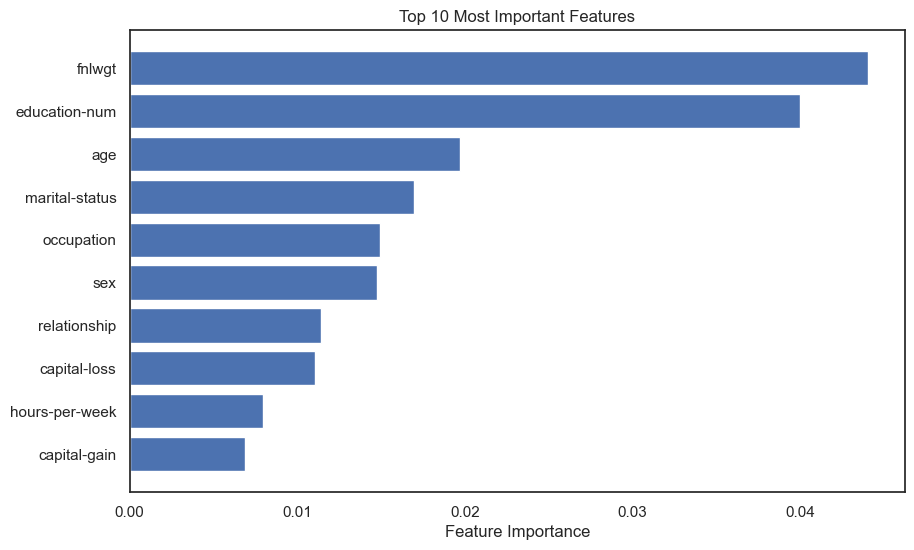

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features[:10])), [val[1] for val in top_10_features], align='center')
plt.yticks(range(len(sorted_features[:10])), [val[0] for val in top_10_features])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

In [55]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = xg2.predict_proba(X_test)[:, 1]
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = auc(fpr,tpr)
print(f'AUC: {auc}')

AUC: 0.923344661409553


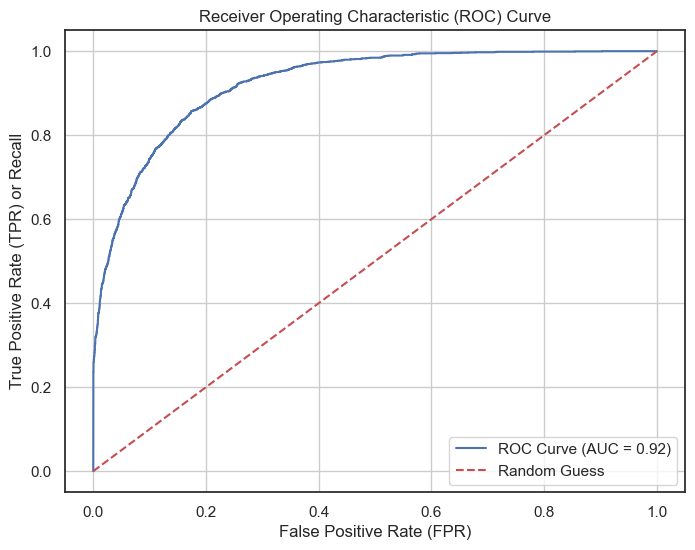

In [56]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) or Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
import joblib

joblib.dump(xg2, "adult_income_pipeline.joblib")

['adult_income_pipeline.joblib']

In [58]:
print(xg2.classes_)

[0 1]


In [59]:
loaded_pipeline = joblib.load("adult_income_pipeline.joblib")

test_row = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(test_row)
probabilities = loaded_pipeline.predict_proba(test_row)

print("Prediction:", prediction)
print("Probabilities:", probabilities)
print("Classes:", loaded_pipeline.classes_)

Prediction: [0]
Probabilities: [[0.98162544 0.01837458]]
Classes: [0 1]


In [60]:
original_prediction = xg2.predict(X_test.iloc[[0]])
loaded_prediction = loaded_pipeline.predict(X_test.iloc[[0]])

print(original_prediction)
print(loaded_prediction)

[0]
[0]


In [61]:
classes = loaded_pipeline.classes_

positive_class = 1
positive_index = list(classes).index(positive_class)

probability_above_50k = probabilities[0][positive_index]

In [62]:
probability_above_50k

np.float32(0.018374579)